# 🎓 Sistema de Previsão de Risco Acadêmico

Este projeto cria um sistema de previsão de risco acadêmico permitindo que a escola planeje intervenções acadêmicas em grupos de risco ainda durante o ano letivo.

# 1 - Contexto
O sucesso nas taxas de aprovação de alunos em uma escola podem ser melhorados ainda durante o ano letivo se a escola destinar intervenções pedagógica convenientes para cada grupo de alunos. Ao invés de esperar o fim do ano para somente medir as taxas de aprovação e planejar mudanças para o ano seguinte, ao se fazer uso de um sistema de previsão de aprovação, a escola pode ativamente melhorar seus índices ainda durante o ano letivo.

Este projeto propõe um modelo de Machine Learning que:
- Utiliza dados acadêmicos dos três primeiros bimestres;
- Prevê a situação final do aluno;
- Apoia a tomada de decisão pedagógica baseada em dados;

O sistema pode ser utilizado por coordenações pedagógicas para:
- Direcionar reforço escolar;
- Avaliar políticas de avaliação (provas x trabalhos);
- Reduzir taxas de reprovação;

# 2 - Objetivo
Este projeto tem como objetivo desenvolver um sistema de previsão de risco acadêmico
capaz de identificar, ainda durante o ano letivo, alunos com maior probabilidade de:

🟢 Aprovação;

🟡 Recuperação;

🔴 Reprovação;

A previsão é realizada ao final do **3º bimestre**, permitindo que a escola
implemente intervenções pedagógicas no último período do ano.

# 3 - Dados

Para este projeto os dados foram gerados de forma sintética para fins educacionais e demonstrar o método de previsão de risco acadêmico.
Os dados estão estruturados de acordo com o sistema simples pensado para uma escola:

## 3.1 Estrutura de Avaliação Escolar

O ano letivo é dividido em quatro bimestres.

Para cada bimestre, o aluno possui:
- 1 prova (valor máximo: 8 pontos)
- 2 trabalhos (valor máximo: 1 ponto cada)
- Frequência percentual no bimestre

Nota máxima por bimestre: **10 pontos**
Nota final: Média das notas dos quatro bimestres.
Frequência final: Percentual total da frequência ao longo do ano.

Ao final do quarto bimestre, de acordo com as regras abaixo, o aluno estará em um dos três status de aprovação:

| Classe          | Condição                                  |
| --------------- | ----------------------------------------- |
| **Aprovado**    | nota_final ≥ 7 **e** frequência ≥ 75%     |
| **Recuperação** | 5 ≤ nota_final < 7 **e** frequência ≥ 75% |
| **Reprovado**   | nota_final < 5 **ou** frequência < 75%    |


# 4 - Ferramentas utilizadas

- Python;
- Numpy;
- Pandas;
- Sklearn;


# 5 - Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)


# 6 - Criação do Dataset sintético



In [2]:
# Gerar dados aleatórios que simulem informações de alunos

np.random.seed(42)

# Definir número total de alunos no dataset criado
n_alunos = 800

# Cria um DataFrame com três colunas e o intervalo dos dados
df = pd.DataFrame({
    'id_aluno': range(1, n_alunos + 1),
    'idade': np.random.randint(11, 15, n_alunos),
    'serie': np.random.choice([6, 7, 8, 9], n_alunos)
})

In [3]:
# Função para gerar dados bimestrais (notas de provas, trabalhos e frequencia)

def gerar_bimestre(df, bimestre):
  df[f'prova_b{bimestre}'] = np.round(np.random.uniform(3, 8, len(df)), 1)
  df[f'trab1_b{bimestre}'] = np.round(np.random.uniform(0, 1, len(df)), 1)
  df[f'trab2_b{bimestre}'] = np.round(np.random.uniform(0, 1, len(df)), 1)
  df[f'freq_b{bimestre}'] = np.round(np.random.uniform(50, 100, len(df)), 1)
  return df

In [4]:
# Aplicação da função para gerar os dados dos 4 bimestres

for b in range(1, 5):
  df = gerar_bimestre(df, b)

In [5]:
# Criação de uma coluna com o cálculo das notas bimestrais

for b in range(1, 5):
  df[f'nota_b{b}'] = (
      df[f'prova_b{b}'] +
      df[f'trab1_b{b}'] +
      df[f'trab2_b{b}']
  )

In [6]:
# Criação de uma coluna com o cálculo das notas e frequencia finais

df['nota_final'] = df[[f'nota_b{b}' for b in range(1, 5)]].mean(axis=1)
df['frequencia_final'] = df[[f'freq_b{b}' for b in range(1, 5)]].mean(axis=1)

In [7]:
# Definição do resultado final de cada aluno

def definir_status(row):
  if row['frequencia_final'] >= 75:
    if row['nota_final'] >= 7:
      return 'Aprovado'
    elif row['nota_final'] >= 5 and row['nota_final'] < 7:
      return 'Recuperação'
    else:
      return 'Reprovado'
  else:
    return 'Reprovado'

df['resultado_final'] = df.apply(definir_status, axis=1)

In [8]:
# Visualização do DataFrame criado
df.head()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final,resultado_final
0,1,13,6,6.5,0.2,0.3,77.7,5.9,0.1,0.3,...,0.2,0.7,77.9,7.0,6.3,6.3,4.8,6.100,72.70,Reprovado
1,2,14,7,3.8,0.3,0.1,75.2,7.0,0.1,0.3,...,0.4,0.1,52.9,4.2,7.4,4.7,4.9,5.300,77.70,Recuperação
2,3,11,6,5.9,0.2,0.4,59.7,6.8,0.9,0.1,...,0.6,0.2,84.8,6.5,7.8,6.2,4.6,6.275,65.80,Reprovado
3,4,13,6,6.0,0.4,0.3,92.9,3.8,0.2,0.7,...,0.8,0.8,52.6,6.7,4.7,5.5,5.6,5.625,72.85,Reprovado
4,5,13,7,5.1,0.1,0.7,83.8,3.7,0.8,0.0,...,0.9,0.5,90.9,5.9,4.5,9.0,9.3,7.175,77.60,Aprovado


In [ ]:
# Salvando o dataset
df.to_csv('../content/sample_data/dados_academicos_bimestrais.csv', index=False)

# 7 - Análise Exploratória de Dados (EDA)

⚠️ Importante: O modelo utilizará apenas informações dos três primeiros bimestres, simulando um cenário real de previsão antes do encerramento do ano letivo.

In [11]:
df.shape

(800, 26)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_aluno          800 non-null    int64  
 1   idade             800 non-null    int64  
 2   serie             800 non-null    int64  
 3   prova_b1          800 non-null    float64
 4   trab1_b1          800 non-null    float64
 5   trab2_b1          800 non-null    float64
 6   freq_b1           800 non-null    float64
 7   prova_b2          800 non-null    float64
 8   trab1_b2          800 non-null    float64
 9   trab2_b2          800 non-null    float64
 10  freq_b2           800 non-null    float64
 11  prova_b3          800 non-null    float64
 12  trab1_b3          800 non-null    float64
 13  trab2_b3          800 non-null    float64
 14  freq_b3           800 non-null    float64
 15  prova_b4          800 non-null    float64
 16  trab1_b4          800 non-null    float64
 1

Os dados estão conforme as instruções durante a criação do dataset tanto para os tipos quanto para o número de variáveis e amostras.


In [13]:
pd.options.display.float_format = '{:.2f}'.format
df = pd.DataFrame (df)
df.describe()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,prova_b4,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,...,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,12.55,7.43,5.50,0.50,0.50,74.56,5.46,0.50,0.50,...,5.57,0.50,0.50,74.56,6.50,6.46,6.36,6.57,6.47,74.73
std,231.08,1.15,1.12,1.46,0.29,0.29,14.36,1.43,0.29,0.29,...,1.43,0.30,0.29,14.65,1.53,1.50,1.50,1.48,0.77,7.14
min,1.00,11.00,6.00,3.00,0.00,0.00,50.00,3.00,0.00,0.00,...,3.00,0.00,0.00,50.10,3.10,3.20,3.40,3.10,4.15,54.40
25%,200.75,12.00,6.00,4.20,0.30,0.30,61.68,4.20,0.30,0.20,...,4.40,0.20,0.20,61.80,5.20,5.20,5.10,5.40,5.92,69.69
50%,400.50,13.00,7.00,5.50,0.50,0.50,74.30,5.50,0.50,0.50,...,5.60,0.50,0.50,74.05,6.50,6.50,6.30,6.60,6.47,74.85
75%,600.25,14.00,8.00,6.70,0.70,0.80,87.40,6.62,0.70,0.72,...,6.80,0.80,0.80,87.22,7.80,7.60,7.60,7.80,7.00,79.57
max,800.00,14.00,9.00,8.00,1.00,1.00,100.00,8.00,1.00,1.00,...,8.00,1.00,1.00,99.90,9.70,9.70,9.90,9.70,8.70,94.60


Observa-se que o dataset não apresenta valores ausentes,
e que as variáveis numéricas estão dentro de intervalos coerentes
com o contexto escolar.


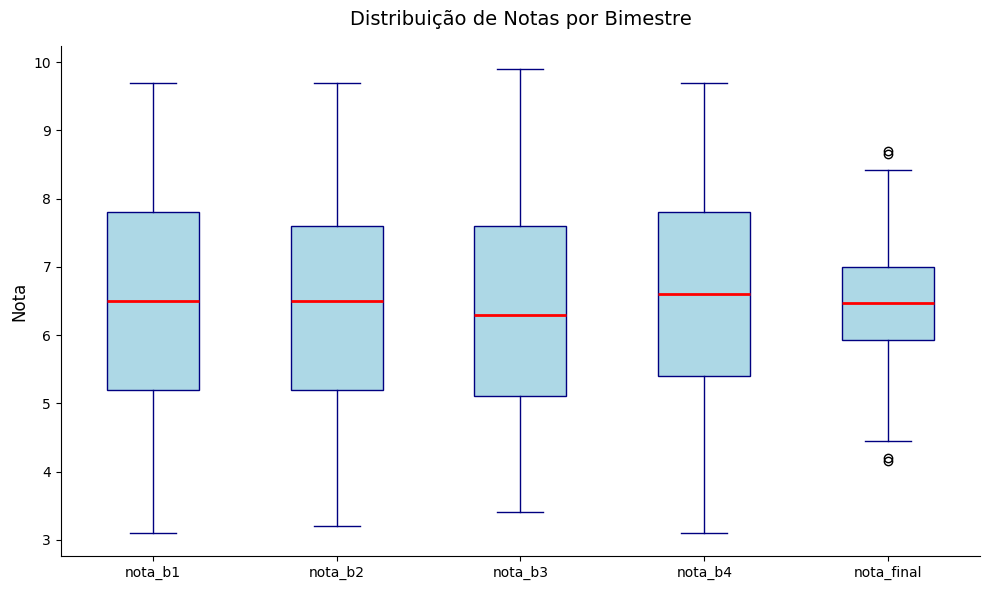

In [14]:
# Geração de um gráfico boxplot comparando a variação das notas bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'nota' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição de Notas por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Nota', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

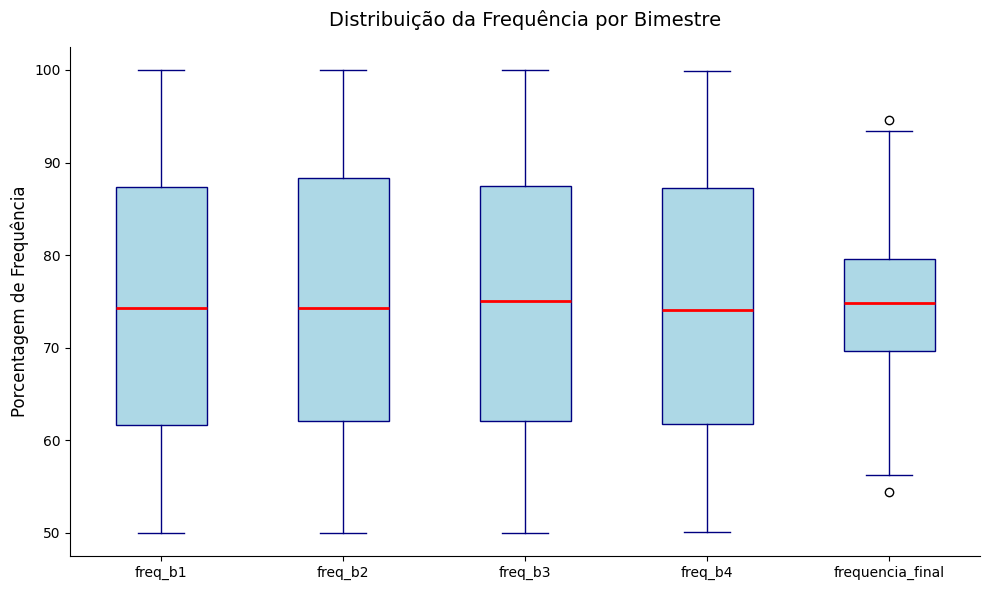

In [15]:
# Geração de um gráfico boxplot comparando a variação das frequências bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'freq' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição da Frequência por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Porcentagem de Frequência', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

Análise de notas por bimestre

In [ ]:
notas_cols = [f'nota_b{b}' for b in range(1, 5)]
df[notas_cols].describe()

,nota_b1,nota_b2,nota_b3,nota_b4
count,800.00,800.00,800.00,800.00
mean,6.50,6.46,6.36,6.57
std,1.53,1.50,1.50,1.48
min,3.10,3.20,3.40,3.10
25%,5.20,5.20,5.10,5.40
50%,6.50,6.50,6.30,6.60
75%,7.80,7.60,7.60,7.80
max,9.70,9.70,9.90,9.70


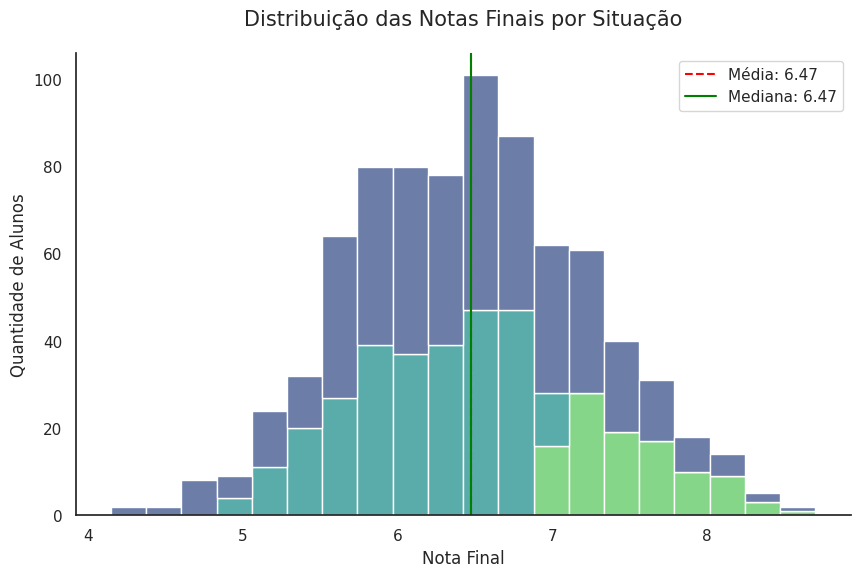

In [17]:
# Geração de um histograma da distribuição das notas finais
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 6))

# Histograma com cores por status
sns.histplot(
    data=df,
    x='nota_final',
    hue='resultado_final',
    multiple="stack",
    palette='viridis',
    edgecolor='white',
    ax=ax
    )

# Adicionando média e mediana
media = df['nota_final'].mean()
mediana = df['nota_final'].median()

ax.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')

ax.set_title('Distribuição das Notas Finais por Situação', fontsize=15, pad=20)
ax.set_xlabel('Nota Final', fontsize=12)
ax.set_ylabel('Quantidade de Alunos', fontsize=12)
ax.legend()

sns.despine()
plt.show()

Frequencia por bimestre

In [ ]:
freq_cols =[f'freq_b{b}' for b in range(1, 5)]
df[freq_cols].describe()

,freq_b1,freq_b2,freq_b3,freq_b4
count,800.00,800.00,800.00,800.00
mean,74.56,74.88,74.91,74.56
std,14.36,14.49,14.49,14.65
min,50.00,50.00,50.00,50.10
25%,61.68,62.10,62.10,61.80
50%,74.30,74.35,75.00,74.05
75%,87.40,88.30,87.53,87.22
max,100.00,100.00,100.00,99.90


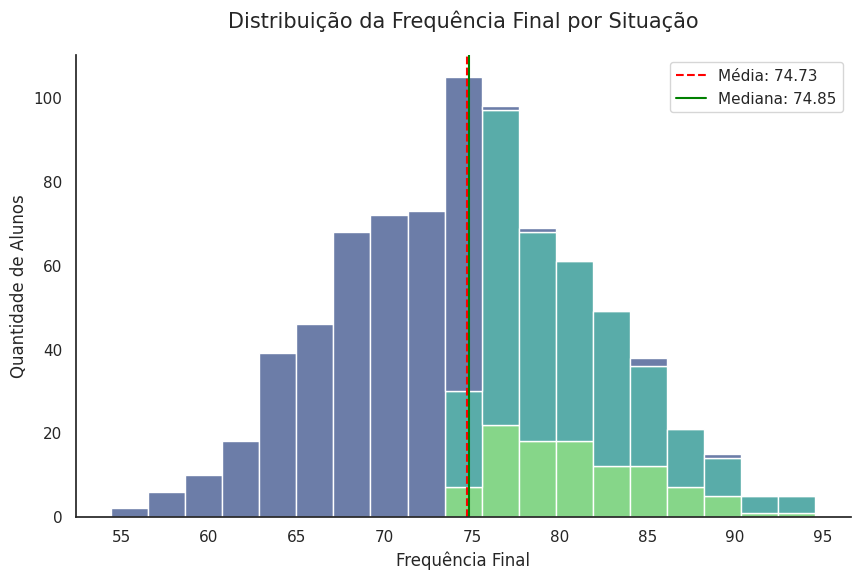

In [21]:
# Geração de um histograma da distribuição das frequências finais
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 6))

# Histograma com cores por status
sns.histplot(
    data=df,
    x='frequencia_final',
    hue='resultado_final',
    multiple="stack",
    palette='viridis',
    edgecolor='white',
    ax=ax
    )

# Adicionando média e mediana
media = df['frequencia_final'].mean()
mediana = df['frequencia_final'].median()

ax.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')

ax.set_title('Distribuição da Frequência Final por Situação', fontsize=15, pad=20)
ax.set_xlabel('Frequência Final', fontsize=12)
ax.set_ylabel('Quantidade de Alunos', fontsize=12)
ax.legend()

sns.despine()
plt.show()

In [ ]:
# Verificação se o dataset está equilibrado entre a distribuição das categorias
df['resultado_final'].value_counts(normalize=True)

,proportion
resultado_final,
Reprovado,0.51750
Recuperação,0.35375
Aprovado,0.12875


<Axes: title={'center': 'Distribuição das Classes (Em %)'}, xlabel='Resultado Final', ylabel='Porcentagem'>

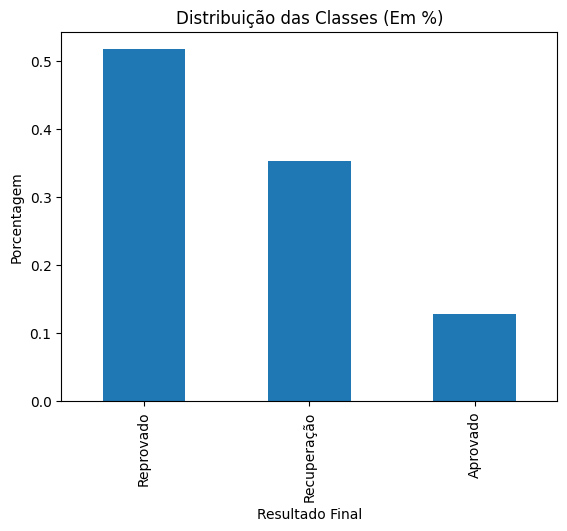

In [ ]:
df['resultado_final'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição das Classes (Em %)',
    xlabel='Resultado Final',
    ylabel='Porcentagem'
    )

A distribuição dos alunos entre os três resultados de aprovação ficou um pouco desbalanceada, o que demandará atenção nas etapas de geração dos modelos, pois o fato de haver mais alunos no status "Reprovado" pode viciar o modelo. Algumas correções serão aplicadas quando necessário.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_aluno          800 non-null    int64  
 1   idade             800 non-null    int64  
 2   serie             800 non-null    int64  
 3   prova_b1          800 non-null    float64
 4   trab1_b1          800 non-null    float64
 5   trab2_b1          800 non-null    float64
 6   freq_b1           800 non-null    float64
 7   prova_b2          800 non-null    float64
 8   trab1_b2          800 non-null    float64
 9   trab2_b2          800 non-null    float64
 10  freq_b2           800 non-null    float64
 11  prova_b3          800 non-null    float64
 12  trab1_b3          800 non-null    float64
 13  trab2_b3          800 non-null    float64
 14  freq_b3           800 non-null    float64
 15  prova_b4          800 non-null    float64
 16  trab1_b4          800 non-null    float64
 1

In [50]:
# Mapa de calor para as correlações
colunas_numericas = df.select_dtypes(include=["float64", "int64"]).columns
colunas_numericas = colunas_numericas.drop(['id_aluno', 'serie'])
corr = df[colunas_numericas].corr()

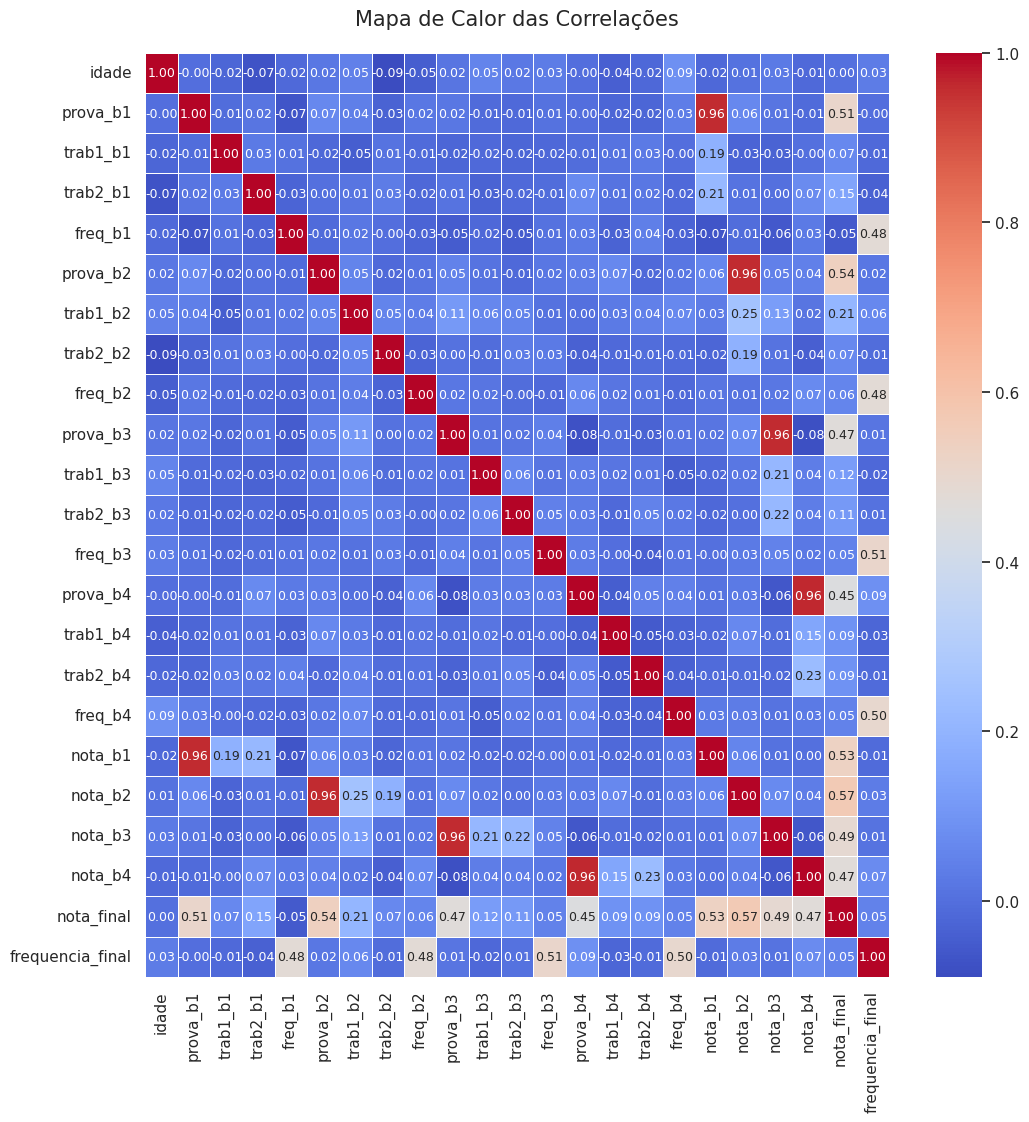

In [60]:
# Criação de um mapa de calor das correlações
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 9}
    )
plt.title('Mapa de Calor das Correlações', fontsize=15, pad=20)
plt.show()

As maiores correlações são encontradas entre as provas bimestrais e as respectivas notas do bimestre. Como a nota da prova constitui 80% da nota do bimestre, essa é uma correlação esperada.


Distribuição da variável alvo por classse

In [62]:
df['resultado_final'].value_counts(normalize=True)

,proportion
resultado_final,
Reprovado,0.52
Recuperação,0.35
Aprovado,0.13


A distribuição dos alunos pelas classes do resultado final está desbalanceada. A diferença entre as classes pode gerar influências durante o treinamento do modelo. Como consequência, o modelo pode tender a classificar a maioria das instâncias como a classe majoritária, ignorando a minoritária.

Algumas correções deverão ser aplicadas na estapa de teste dos modelos para evitar estes problemas. Existem técnicas para lidar com o desbalanceamento, como oversampling da classe minoritária, undersampling da classe majoritária, ou o uso de pesos de classe nos algoritmos de treinamento.

In [63]:
print('Idades presentes:', df['idade'].unique())
print('Séreis presentes: ', df['serie'].unique())

Idades presentes: [13 14 11 12]
Séreis presentes:  [6 7 9 8]


In [65]:
df['serie'].value_counts(normalize=True)

,proportion
serie,
6,0.27
7,0.25
8,0.25
9,0.23


In [67]:
df['idade'].value_counts(normalize=True)

,proportion
idade,
14,0.28
11,0.25
13,0.23
12,0.23


# 8 - Definição do conjunto de features

Serão criadas variáveis agregadas utilizando apenas os três primeiros bimestres,
evitando qualquer vazamento de informação do 4º bimestre.



In [72]:
#
df['media_nota_b1_b3'] = df[[f'nota_b{b}' for b in range(1, 4)]].mean(axis=1)
df['media_freq_b1_b3'] = df[[f'freq_b{b}' for b in range(1, 4)]].mean(axis=1)

df['total_trabalhos_b1_b3'] = (
    df[[f'trab1_b{b}' for b in range(1, 4)]].sum(axis=1) +
    df[[f'trab2_b{b}' for b in range(1, 4)]].sum(axis=1)
)


Essas variáveis representam uma visão consolidada do desempenho do aluno
até o terceiro bimestre.


In [97]:
# Features básicas (até b3)
features_basico = [
    'prova_b1','prova_b2','prova_b3',
    'trab1_b1','trab1_b2','trab1_b3',
    'trab2_b1','trab2_b2','trab2_b3',
    'freq_b1','freq_b2','freq_b3',
    'idade','serie'
]

# Features avançadas (inclui agregados)
df['slope_nota'] = df['nota_b3'] - df['nota_b1']
df['var_nota'] = df[['nota_b1','nota_b2','nota_b3']].var(axis=1)
df['media_nota_b1_b3'] = df[['nota_b1','nota_b2','nota_b3']].mean(axis=1)
df['media_freq_b1_b3'] = df[['freq_b1','freq_b2','freq_b3']].mean(axis=1)

features_avancado = features_basico + [
    'media_nota_b1_b3','media_freq_b1_b3',
    'slope_nota','var_nota'
]

In [118]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   prova_b1          800 non-null    float64
 1   prova_b2          800 non-null    float64
 2   prova_b3          800 non-null    float64
 3   trab1_b1          800 non-null    float64
 4   trab1_b2          800 non-null    float64
 5   trab1_b3          800 non-null    float64
 6   trab2_b1          800 non-null    float64
 7   trab2_b2          800 non-null    float64
 8   trab2_b3          800 non-null    float64
 9   freq_b1           800 non-null    float64
 10  freq_b2           800 non-null    float64
 11  freq_b3           800 non-null    float64
 12  idade             800 non-null    int64  
 13  serie             800 non-null    int64  
 14  media_nota_b1_b3  800 non-null    float64
 15  media_freq_b1_b3  800 non-null    float64
 16  slope_nota        800 non-null    float64
 1

In [103]:
# Definição X
X= df[features_avancado]
y = df['resultado_final']

In [104]:
## Codificação da variável alvo

y = y.map({
    'Reprovado': 0,
    'Recuperação': 1,
    'Aprovado': 2
})


In [107]:
df_modelo = pd.concat([X, y.rename('resultado_final')], axis=1)
df_modelo.head()

,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,6.50,5.90,4.80,0.20,0.10,0.70,0.30,0.30,0.80,77.70,84.20,51.00,13,6,6.53,70.97,-0.70,0.16,0
1,3.80,7.00,3.70,0.30,0.10,0.70,0.10,0.30,0.30,75.20,94.10,88.60,14,7,5.43,85.97,0.50,2.96,1
2,5.90,6.80,5.60,0.20,0.90,0.10,0.40,0.10,0.50,59.70,60.20,58.50,11,6,6.83,59.47,-0.30,0.72,0
3,6.00,3.80,3.60,0.40,0.20,0.90,0.30,0.70,1.00,92.90,93.70,52.20,13,6,5.63,79.60,-1.20,1.01,0
4,5.10,3.70,7.70,0.10,0.80,0.60,0.70,0.00,0.70,83.80,53.00,82.70,13,7,6.47,73.17,3.10,5.30,2


Dataset final para ML

Salvando dataset preparado

In [96]:
df_modelo = pd.concat([X, y.rename('resultado_final')], axis=1)
#df_modelo.to_csv('../content/sample_data/dados_modelo_b1_b3.csv')

TypeError: Index(...) must be called with a collection of some kind, 'resultado_final' was passed

## Conclusão

Neste notebook realizamos:
- Análise exploratória dos dados acadêmicos
- Criação de features agregadas até o 3º bimestre
- Preparação do dataset para modelagem preditiva
- Garantia de ausência de vazamento de dados

O próximo passo será a construção e avaliação dos modelos de Machine Learning.


# Modelagem preditiva e Avaliação

Separação de features e target

In [109]:
X = df_modelo.drop(columns=['resultado_final'])
y = df_modelo['resultado_final']

A variável alvo representa a situação final do aluno:
- 0 → Reprovado
- 1 → Recuperação
- 2 → Aprovado


Train/Test Split

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# o uso de stratify=y garante que a proporção das classes seja mantida nos conjuntos de treino e teste

# Modelo 1: Regressão Logística Multiclasse
## Modelo 1 — Regressão Logística Multiclasse

A Regressão Logística Multinomial é utilizada como baseline por ser:
- Interpretável
- Rápida
- Capaz de retornar probabilidades por classe


Treinamento da regressão logistica

In [111]:
log_reg = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)

Avaliação da Regressão Logística

In [112]:
yPred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, yPred_lr))
print("F1-score (macro):", f1_score(y_test, yPred_lr, average='macro'))
print(confusion_matrix(y_test, yPred_lr))
print(classification_report(y_test, yPred_lr))


Accuracy: 0.70625
F1-score (macro): 0.6501744056120714
[[66 15  2]
 [15 38  4]
 [ 5  6  9]]
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        83
           1       0.64      0.67      0.66        57
           2       0.60      0.45      0.51        20

    accuracy                           0.71       160
   macro avg       0.67      0.64      0.65       160
weighted avg       0.70      0.71      0.70       160



O F1-score macro é utilizado para avaliar o desempenho médio entre as classes,
independente do seu tamanho.


# Cross validation (logistic regression)

In [113]:
cv_lr = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (LogReg): ", cv_lr.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

F1 Macro CV (LogReg):  0.6764626752056698


# Model 2: *RandomForest*
## Modelo 2 — Random Forest

O Random Forest é um modelo de ensemble capaz de capturar relações
não lineares e interações complexas entre variáveis acadêmicas.


In [114]:
# Treinamento do Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = 'balanced'
    )

# Treinar o modelo
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [115]:
# Avaliaçao do Random Forest

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score (macro):", f1_score(y_test, y_pred_rf, average='macro'))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.70625
F1-score (macro): 0.653620725989147
[[68 15  0]
 [15 35  7]
 [ 5  5 10]]
              precision    recall  f1-score   support

           0       0.77      0.82      0.80        83
           1       0.64      0.61      0.62        57
           2       0.59      0.50      0.54        20

    accuracy                           0.71       160
   macro avg       0.67      0.64      0.65       160
weighted avg       0.70      0.71      0.70       160



# Crox validation random forest

In [116]:
cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (Random Forest): ", cv_rf.mean())

F1 Macro CV (Random Forest):  0.6999761333512884


# Comparação dos modelos
## Comparação dos Modelos

Os modelos foram comparados utilizando:
- F1-score macro
- Resultados de cross-validation
- Matriz de confusão

Essa abordagem permite avaliar não apenas a acurácia geral,
mas também o desempenho em cada classe de risco acadêmico.


In [117]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importances

,feature,importance
15,media_freq_b1_b3,0.20
14,media_nota_b1_b3,0.16
10,freq_b2,0.08
11,freq_b3,0.08
2,prova_b3,0.07
9,freq_b1,0.07
0,prova_b1,0.06
1,prova_b2,0.04
16,slope_nota,0.04
17,var_nota,0.04


A análise de importância das variáveis permite compreender
quais fatores mais influenciam a situação final dos alunos,
apoiando decisões pedagógicas baseadas em evidências.


## Interpretação dos Resultados

Os resultados indicam que:
- O desempenho nas provas dos primeiros bimestres
- A frequência escolar
- A participação em trabalhos

são fatores determinantes para a situação final do aluno.

Essas informações podem ser utilizadas para:
- Identificar alunos em risco no 3º bimestre
- Direcionar ações de reforço escolar
- Avaliar o impacto das atividades avaliativas


## Limitações

- Os dados utilizados são sintéticos
- O modelo não substitui avaliação pedagógica humana
- Resultados devem ser interpretados como apoio à decisão

Apesar disso, o projeto demonstra um pipeline completo
de Data Science aplicado a um problema real.


## Conclusão

Este notebook apresentou:
- Modelagem multiclasse com foco em risco acadêmico
- Comparação entre modelos interpretáveis e ensembles
- Avaliação robusta com cross-validation
- Interpretação orientada ao contexto educacional

O sistema proposto pode servir como base para soluções
de análise preditiva no ambiente escolar.
